# 04 — High-detail class-conditional spatial VAE V3

This notebook contains **Version 3** of the conditional VAE for the normalized
`128×128` log-mel spectrograms created by notebook `02`.

## What V3 changes relative to V2

| Component | V2 | V3 | Intended effect |
|---|---|---|---|
| Spatial latent | `16×8×8` (1,024 values) | `16×16×16` (4,096 values) | Preserve short transients and narrow harmonics at finer locations |
| KL objective | Linear warmup, fixed beta `1e-3` | Per-channel free bits, beta `5e-4`, longer warmup | Retain useful detail without abandoning latent regularization |
| Reconstruction guidance | Weighted/multiscale/gradient losses | V2 losses plus frozen classifier feature and label consistency | Preserve species-discriminative syllables and frequency contours |
| Conditional sampling | One diagonal moment-matched Gaussian per species | Per-species posterior-anchor mixture with controlled noise | Preserve correlations between neighboring spatial latent positions |
| Auditability | Generated sample metadata | Adds the selected training anchor and posterior temperature | Make the fidelity-versus-independence tradeoff explicit |
| Artifacts | `_v2` directories | isolated `_v3` directories | Never overwrite V2 checkpoints or results |

V3 keeps V2's residual blocks, FiLM species conditioning, resize-convolution,
event-weighted multiscale reconstruction loss, time/frequency gradient losses,
deterministic posterior-mean validation, and classifier-input adapter.

The existing trained V3 checkpoint is loaded by default for reproducible
evaluation (`RUN_TRAINING=False`). Set it to `True` only when intentionally
retraining. Waveforms are exported separately with
`scripts/05_export_generated_audio.py --no-peak-normalize`.


## 1. Environment and dependencies

Required packages: `numpy`, `pandas`, `matplotlib`, and `torch`.

On Windows, `NUM_WORKERS = 0` is the safest Jupyter default. Mixed precision is
enabled automatically only when CUDA is available.


In [1]:
from __future__ import annotations

import json
import math
import random
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Audio, display
from torch.utils.data import DataLoader, Dataset

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.12.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti


## 2. V3 configuration and experiment isolation

Notebook `02` remains the data contract. V3 writes only to
`checkpoints/conditional_vae_v3` and `outputs/conditional_vae_v3`; the V2
directories are read only for metric comparison. Evaluation mode loads the
already-trained best V3 checkpoint and regenerates summaries and samples.


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))


@dataclass
class Config:
    # Paths
    PROJECT_ROOT: str = str(PROJECT_ROOT)
    SPECTROGRAM_CACHE_DIR: str = "artifacts/spectrograms"
    MANIFEST_DIR: str = "artifacts/spectrograms/manifests"
    TRAIN_MANIFEST: str = "spectrogram_train.csv"
    VAL_MANIFEST: str = "spectrogram_validation.csv"
    TEST_MANIFEST: str = "spectrogram_test.csv"
    NORMALIZATION_STATS: str = "artifacts/spectrograms/manifests/normalization_stats.json"
    PREPROCESSING_CONFIG: str = "artifacts/spectrograms/manifests/preprocessing_config.json"
    CLASSIFIER_CHECKPOINT: str = "classifier_artifacts/Harvey_classifier/best.pt"
    CHECKPOINT_DIR: str = "checkpoints/conditional_vae_v3"
    OUTPUT_DIR: str = "outputs/conditional_vae_v3"
    V2_OUTPUT_DIR: str = "outputs/conditional_vae_v2"

    # Reproducibility and loading
    SEED: int = 42
    NUM_WORKERS: int = 0
    PIN_MEMORY: bool = True

    # Data contract from notebook 02
    INPUT_CHANNELS: int = 1
    IMAGE_SIZE: int = 128
    TARGET_SPECIES: Tuple[str, ...] = (
        "Northern Cardinal",
        "Song Sparrow",
        "American Robin",
    )
    SPEC_PATH_CANDIDATES: Tuple[str, ...] = (
        "relative_spec_path",
        "spec_path",
        "spectrogram_path",
        "logmel_path",
        "npy_path",
        "processed_path",
    )
    SPECIES_COLUMN_CANDIDATES: Tuple[str, ...] = (
        "name",
        "species",
        "species_name",
        "label_name",
    )
    GROUP_COLUMN_CANDIDATES: Tuple[str, ...] = (
        "id",
        "recording_id",
        "original_recording_id",
        "xc_id",
    )

    # V3 spatial residual CVAE
    LATENT_CHANNELS: int = 16
    LATENT_SIZE: int = 16
    CLASS_EMBED_DIM: int = 64
    BASE_CHANNELS: int = 32

    # V2 detail losses plus V3 regularizers
    EVENT_WEIGHT: float = 1.5
    MULTISCALE_WEIGHT: float = 0.25
    TIME_GRAD_WEIGHT: float = 0.60
    FREQ_GRAD_WEIGHT: float = 0.60
    CLASSIFIER_FEATURE_WEIGHT: float = 0.08
    CLASSIFIER_LABEL_WEIGHT: float = 0.03
    CLASSIFIER_LOSS_WARMUP_EPOCHS: int = 8
    BETA_KL: float = 5e-4
    KL_WARMUP_EPOCHS: int = 20
    FREE_NATS_PER_CHANNEL: float = 0.25

    # Optimization
    BATCH_SIZE: int = 24
    MAX_EPOCHS: int = 60
    LEARNING_RATE: float = 2e-4
    WEIGHT_DECAY: float = 1e-5
    GRAD_CLIP_NORM: float = 5.0
    EARLY_STOPPING_PATIENCE: int = 12
    MIN_DELTA: float = 1e-4
    AMP: bool = True

    # Default to reproducible evaluation of the existing trained V3 model.
    RUN_TRAINING: bool = False
    RESUME_FROM_LAST: bool = False
    SMOKE_TEST: bool = False
    SMOKE_TEST_BATCHES: int = 3
    SMOKE_TEST_EPOCHS: int = 2
    SAMPLES_PER_SPECIES: int = 16
    PRIOR_BANK_SIZE_PER_SPECIES: int = 256
    PRIOR_TEMPERATURE: float = 0.35


cfg = Config()
PROJECT_ROOT = Path(cfg.PROJECT_ROOT).resolve()
MANIFEST_DIR = PROJECT_ROOT / cfg.MANIFEST_DIR
CHECKPOINT_DIR = PROJECT_ROOT / cfg.CHECKPOINT_DIR
OUTPUT_DIR = PROJECT_ROOT / cfg.OUTPUT_DIR
V2_OUTPUT_DIR = PROJECT_ROOT / cfg.V2_OUTPUT_DIR

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(cfg.AMP and DEVICE.type == "cuda")

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Mixed precision:", AMP_ENABLED)
print("Run training:", cfg.RUN_TRAINING)
print("Smoke test:", cfg.SMOKE_TEST)
print("V3 output isolation:", OUTPUT_DIR)


Project root: C:\Users\sheng\Documents\1508_project\bird_song_gen
Device: cuda
Mixed precision: True
Run training: False
Smoke test: False
V3 output isolation: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v3


In [3]:
PREPROCESSING_CONFIG_PATH = PROJECT_ROOT / cfg.PREPROCESSING_CONFIG
if not PREPROCESSING_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Missing preprocessing contract: {PREPROCESSING_CONFIG_PATH}\n"
        "Run notebook 02 first, or update PREPROCESSING_CONFIG in Config."
    )

with PREPROCESSING_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    preprocessing_config = json.load(handle)

preprocessed_shape = preprocessing_config.get("output", {}).get("shape")
preprocessed_species = preprocessing_config.get("target_species")
expected_shape = [cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE]

if preprocessed_shape != expected_shape:
    raise ValueError(
        f"Notebook 02 reports output shape {preprocessed_shape}; "
        f"this model expects {expected_shape}."
    )
if preprocessed_species != list(cfg.TARGET_SPECIES):
    raise ValueError(
        f"Notebook 02 reports species {preprocessed_species}; "
        f"this model expects {list(cfg.TARGET_SPECIES)}."
    )

print("Loaded preprocessing contract:", PREPROCESSING_CONFIG_PATH)
print("Preprocessed shape:", preprocessed_shape)
print("Preprocessed species:", preprocessed_species)


Loaded preprocessing contract: C:\Users\sheng\Documents\1508_project\bird_song_gen\artifacts\spectrograms\manifests\preprocessing_config.json
Preprocessed shape: [1, 128, 128]
Preprocessed species: ['Northern Cardinal', 'Song Sparrow', 'American Robin']


## 3. Reproducibility helpers

Deterministic settings improve repeatability, although exact GPU results can
still vary slightly across PyTorch/CUDA versions.


In [4]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(cfg.SEED)
generator = torch.Generator().manual_seed(cfg.SEED)


## 4. Load manifests and establish the label mapping

The split created in `01_dataset_audit.ipynb` must remain fixed. This section
also checks that an original recording ID does not occur in more than one split.

The notebook derives a deterministic label mapping from the selected species,
so it works even if the manifest does not already contain `label_id`.


In [5]:
def first_existing_column(df: pd.DataFrame, candidates: Tuple[str, ...], purpose: str) -> str:
    for column in candidates:
        if column in df.columns:
            return column
    raise KeyError(
        f"Could not find a {purpose} column. Tried {list(candidates)}. "
        f"Available columns: {df.columns.tolist()}"
    )


def load_manifest(filename: str, split: str) -> pd.DataFrame:
    path = MANIFEST_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {split} manifest: {path}\n"
            "Run notebook 02 first, or update the path in Config."
        )
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"{split} manifest is empty: {path}")
    df = df.copy()
    df["split"] = split
    return df


train_df = load_manifest(cfg.TRAIN_MANIFEST, "train")
val_df = load_manifest(cfg.VAL_MANIFEST, "validation")
test_df = load_manifest(cfg.TEST_MANIFEST, "test")

SPECIES_COL = first_existing_column(
    train_df, cfg.SPECIES_COLUMN_CANDIDATES, "species"
)
SPEC_PATH_COL = first_existing_column(
    train_df, cfg.SPEC_PATH_CANDIDATES, "spectrogram path"
)

for split_name, frame in [("validation", val_df), ("test", test_df)]:
    if SPECIES_COL not in frame.columns or SPEC_PATH_COL not in frame.columns:
        raise KeyError(
            f"{split_name} manifest must contain {SPECIES_COL!r} and {SPEC_PATH_COL!r}."
        )

target_species = list(cfg.TARGET_SPECIES)
for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    unexpected = sorted(set(frame[SPECIES_COL].dropna().unique()) - set(target_species))
    missing = sorted(set(target_species) - set(frame[SPECIES_COL].dropna().unique()))
    if unexpected:
        print(f"Warning: {split_name} has non-target species that will be removed: {unexpected}")
    if missing:
        raise ValueError(f"{split_name} is missing target species: {missing}")

train_df = train_df[train_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)
val_df = val_df[val_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)
test_df = test_df[test_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)

label_to_id = {species: idx for idx, species in enumerate(target_species)}
id_to_label = {idx: species for species, idx in label_to_id.items()}

for frame in (train_df, val_df, test_df):
    frame["label_id"] = frame[SPECIES_COL].map(label_to_id).astype(int)

summary = pd.concat(
    [
        train_df.groupby(SPECIES_COL).size().rename("train"),
        val_df.groupby(SPECIES_COL).size().rename("validation"),
        test_df.groupby(SPECIES_COL).size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int).reindex(target_species)

display(summary)
print("Label mapping:", label_to_id)
print("Total clips:", int(summary.to_numpy().sum()))


,train,validation,test
name,,,
Northern Cardinal,740,172,162
Song Sparrow,890,184,182
American Robin,709,163,145


Label mapping: {'Northern Cardinal': 0, 'Song Sparrow': 1, 'American Robin': 2}
Total clips: 3347


In [6]:
def find_common_group_column(frames: List[pd.DataFrame]) -> Optional[str]:
    for column in cfg.GROUP_COLUMN_CANDIDATES:
        if all(column in frame.columns for frame in frames):
            return column
    return None


GROUP_COL = find_common_group_column([train_df, val_df, test_df])
if GROUP_COL is None:
    print(
        "Warning: no original-recording ID column was found, so group leakage "
        "cannot be checked here. The split should already have been checked in notebook 01."
    )
else:
    train_groups = set(train_df[GROUP_COL].astype(str))
    val_groups = set(val_df[GROUP_COL].astype(str))
    test_groups = set(test_df[GROUP_COL].astype(str))
    overlaps = {
        "train_validation": train_groups & val_groups,
        "train_test": train_groups & test_groups,
        "validation_test": val_groups & test_groups,
    }
    assert all(len(values) == 0 for values in overlaps.values()), (
        "Original recording IDs cross split boundaries: "
        + str({key: list(value)[:5] for key, value in overlaps.items() if value})
    )
    print(f"No group leakage detected using column {GROUP_COL!r}.")


No group leakage detected using column 'id'.


## 5. Resolve and validate spectrogram paths

Paths in a CSV may be absolute or relative. Relative paths are tested against
the project root, the processed directory, and the manifest directory. This
cell validates every file before training begins.


In [7]:
def resolve_spec_path(path_value: str) -> Path:
    raw = Path(str(path_value))
    candidates = [raw] if raw.is_absolute() else [
        PROJECT_ROOT / raw,
        PROJECT_ROOT / cfg.SPECTROGRAM_CACHE_DIR / raw,
        MANIFEST_DIR / raw,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return candidates[0].resolve()


for frame in (train_df, val_df, test_df):
    frame["resolved_spec_path"] = frame[SPEC_PATH_COL].map(resolve_spec_path)

missing_paths = []
for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = frame.loc[~frame["resolved_spec_path"].map(Path.exists), "resolved_spec_path"]
    missing_paths.extend([(split_name, str(path)) for path in missing.head(10)])
    print(f"{split_name:10s}: {len(frame):5d} rows, {len(missing):3d} missing tensors")

if missing_paths:
    raise FileNotFoundError(
        "Some preprocessed tensors are missing. First examples:\n"
        + "\n".join(f"  {split}: {path}" for split, path in missing_paths)
    )

# Inspect a few files before constructing data loaders.
for path in train_df["resolved_spec_path"].head(5):
    array = np.load(path, mmap_mode="r")
    assert array.shape == (cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), (
        f"Unexpected shape {array.shape} in {path}"
    )
    assert array.dtype == np.float32, f"Expected float32, got {array.dtype} in {path}"
    assert np.isfinite(array).all(), f"Non-finite values found in {path}"

print("Initial tensor checks passed.")


train     :  2339 rows,   0 missing tensors
validation:   519 rows,   0 missing tensors
test      :   489 rows,   0 missing tensors
Initial tensor checks passed.


## 6. Dataset and data loaders

Each item is returned as `(spectrogram, label_id, path)`. The path is retained
for traceability and later qualitative checks.


In [8]:
class BirdSpectrogramDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame):
        self.manifest = manifest.reset_index(drop=True).copy()

    def __len__(self) -> int:
        return len(self.manifest)

    def __getitem__(self, index: int):
        row = self.manifest.iloc[index]
        path = Path(row["resolved_spec_path"])
        array = np.load(path).astype(np.float32, copy=False)
        expected = (cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
        if array.shape != expected:
            raise ValueError(f"Expected {expected}, got {array.shape} in {path}")
        if not np.isfinite(array).all():
            raise ValueError(f"Non-finite values in {path}")
        x = torch.from_numpy(np.array(array, copy=True))
        y = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return x, y, str(path)


train_dataset = BirdSpectrogramDataset(train_df)
val_dataset = BirdSpectrogramDataset(val_df)
test_dataset = BirdSpectrogramDataset(test_df)

loader_kwargs = dict(
    batch_size=cfg.BATCH_SIZE,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=bool(cfg.PIN_MEMORY and DEVICE.type == "cuda"),
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=generator,
    drop_last=False,
    **loader_kwargs,
)
val_loader = DataLoader(val_dataset, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, drop_last=False, **loader_kwargs)

x_batch, y_batch, path_batch = next(iter(train_loader))
print("Batch spectrograms:", tuple(x_batch.shape), x_batch.dtype)
print("Batch labels:", tuple(y_batch.shape), y_batch.dtype)
print("Value range:", float(x_batch.min()), "to", float(x_batch.max()))
print("Mean / std:", float(x_batch.mean()), float(x_batch.std()))
print("First file:", path_batch[0])


Batch spectrograms: (24, 1, 128, 128) torch.float32
Batch labels: (24,) torch.int64
Value range: -1.9107701778411865 to 3.4603352546691895
Mean / std: 0.015782179310917854 1.0416754484176636
First file: C:\Users\sheng\Documents\1508_project\bird_song_gen\artifacts\spectrograms\train\northern_cardinal\302932-13.npy


## 7. Batch sanity check

The tensors are normalized model inputs. For visualization, the notebook tries
to load the training-set normalization mean and standard deviation and converts
them back to the log-mel dB scale. If the statistics file is unavailable, it
plots normalized values and labels them accordingly.


Training normalization mean/std: -51.5400096102764 14.894513218933453


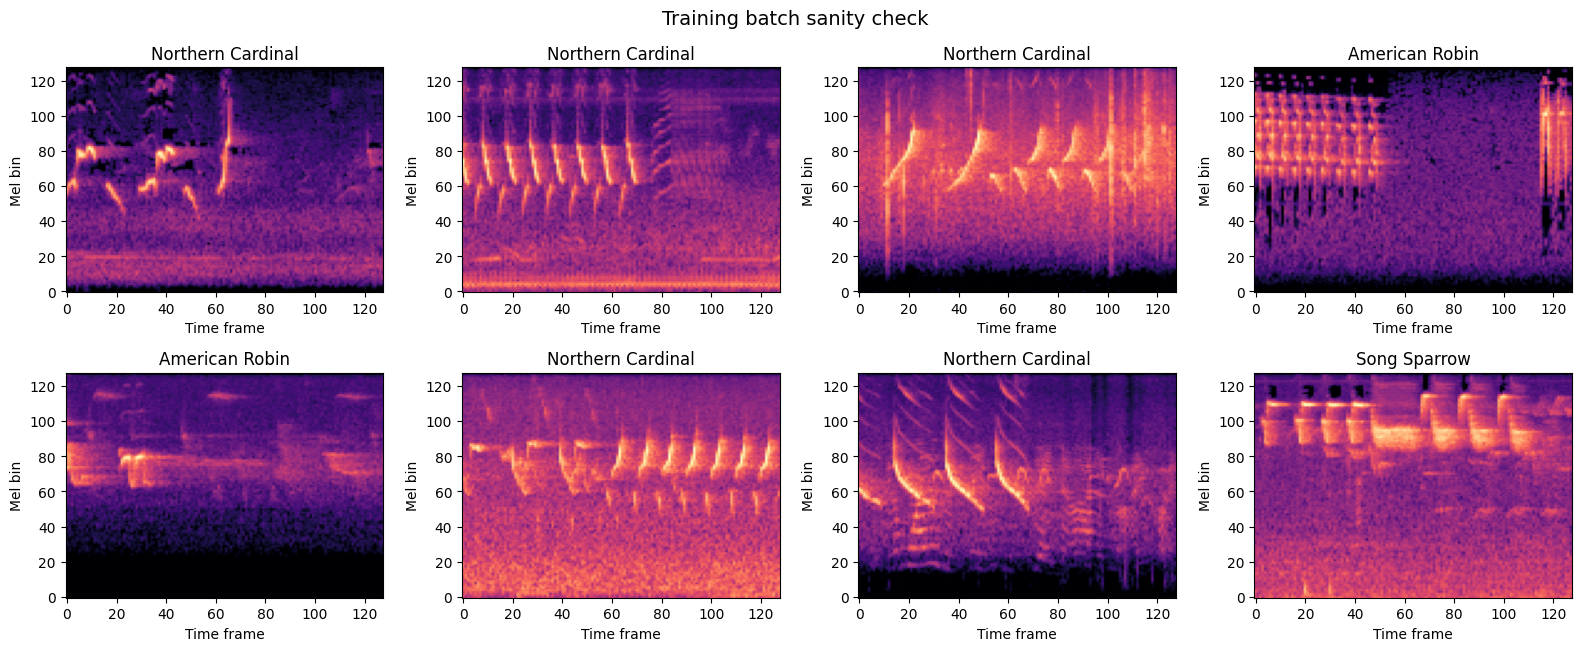

In [9]:
def load_normalization_stats() -> Tuple[Optional[float], Optional[float]]:
    path = PROJECT_ROOT / cfg.NORMALIZATION_STATS
    if not path.exists():
        print("Normalization statistics not found; plots will use normalized units:", path)
        return None, None
    with path.open("r", encoding="utf-8") as handle:
        stats = json.load(handle)

    mean_keys = ("mean_db", "mean", "train_mean", "global_mean", "mu_train")
    std_keys = ("std_db", "std", "train_std", "global_std", "sigma_train")
    mean = next((float(stats[key]) for key in mean_keys if key in stats), None)
    std = next((float(stats[key]) for key in std_keys if key in stats), None)
    if mean is None or std is None:
        print("Could not identify mean/std keys; plots will use normalized units.")
        return None, None
    return mean, std


TRAIN_MEAN, TRAIN_STD = load_normalization_stats()
print("Training normalization mean/std:", TRAIN_MEAN, TRAIN_STD)


def to_display_scale(x: torch.Tensor) -> np.ndarray:
    array = x.detach().cpu().float().numpy()
    if TRAIN_MEAN is not None and TRAIN_STD is not None:
        array = array * TRAIN_STD + TRAIN_MEAN
    return array


def show_spectrogram_grid(
    tensors: torch.Tensor,
    labels: torch.Tensor,
    title: str,
    max_items: int = 8,
) -> None:
    count = min(max_items, len(tensors))
    cols = min(4, count)
    rows = math.ceil(count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.3 * rows), squeeze=False)
    for index, axis in enumerate(axes.flat):
        axis.axis("off")
        if index >= count:
            continue
        image = to_display_scale(tensors[index, 0])
        axis.imshow(image, origin="lower", aspect="auto", cmap="magma")
        axis.set_title(id_to_label[int(labels[index])])
        axis.set_xlabel("Time frame")
        axis.set_ylabel("Mel bin")
        axis.axis("on")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


show_spectrogram_grid(x_batch, y_batch, "Training batch sanity check")


## 8. V3 high-detail spatial conditional VAE

V2 compressed each spectrogram to a `16×8×8` latent map. V3 uses
`16×16×16`, retaining four times as many spatial positions so short events and
narrow frequency tracks do not have to share the same coarse latent cell.
Residual blocks and FiLM species conditioning remain, and resize-convolution
continues to avoid transposed-convolution checkerboard artifacts.


In [10]:
def group_count(channels: int, maximum: int = 8) -> int:
    for groups in range(min(maximum, channels), 0, -1):
        if channels % groups == 0:
            return groups
    return 1


class ConditionalResBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, condition_dim: int):
        super().__init__()
        self.norm1 = nn.GroupNorm(group_count(in_channels), in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(group_count(out_channels), out_channels)
        self.film = nn.Linear(condition_dim, out_channels * 2)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )
        nn.init.zeros_(self.film.weight)
        nn.init.zeros_(self.film.bias)
        nn.init.zeros_(self.conv2.weight)
        nn.init.zeros_(self.conv2.bias)

    def forward(self, x: torch.Tensor, condition: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        h = self.conv1(F.silu(self.norm1(x)))
        h = self.norm2(h)
        scale, shift = self.film(condition).chunk(2, dim=1)
        h = h * (1.0 + 0.1 * torch.tanh(scale[:, :, None, None]))
        h = h + shift[:, :, None, None]
        h = self.conv2(F.silu(h))
        return residual + h


class Downsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=2, padding=1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=False)
        return self.conv(x)


class ConditionalVAE(nn.Module):
    def __init__(
        self,
        num_classes: int,
        image_size: int = 128,
        input_channels: int = 1,
        latent_channels: int = 16,
        latent_size: int = 16,
        class_embed_dim: int = 64,
        base_channels: int = 32,
    ):
        super().__init__()
        ratio = image_size // latent_size
        if image_size % latent_size or ratio < 2 or ratio & (ratio - 1):
            raise ValueError("image_size / latent_size must be a power of two >= 2")
        num_downsamples = int(math.log2(ratio))
        if num_downsamples != 3:
            raise ValueError("V3 expects 128×128 inputs and a 16×16 latent map.")

        self.num_classes = num_classes
        self.image_size = image_size
        self.input_channels = input_channels
        self.latent_channels = latent_channels
        self.latent_size = latent_size
        self.latent_dim = latent_channels * latent_size * latent_size
        self.class_embed_dim = class_embed_dim
        self.base_channels = base_channels

        self.class_embedding = nn.Embedding(num_classes, class_embed_dim)
        channels = [base_channels * multiplier for multiplier in (1, 2, 4, 8)]
        self.encoder_stem = nn.Conv2d(input_channels, channels[0], 3, padding=1)
        self.encoder_blocks = nn.ModuleList(
            [ConditionalResBlock(c, c, class_embed_dim) for c in channels]
        )
        self.downsamples = nn.ModuleList(
            [Downsample(channels[i], channels[i + 1]) for i in range(num_downsamples)]
        )
        self.encoder_tail = ConditionalResBlock(
            channels[-1], channels[-1], class_embed_dim
        )
        self.mu_head = nn.Conv2d(channels[-1], latent_channels, 3, padding=1)
        self.logvar_head = nn.Conv2d(channels[-1], latent_channels, 3, padding=1)

        self.decoder_stem = nn.Conv2d(latent_channels, channels[-1], 3, padding=1)
        self.decoder_tail = ConditionalResBlock(
            channels[-1], channels[-1], class_embed_dim
        )
        reversed_channels = list(reversed(channels))
        self.upsamples = nn.ModuleList(
            [
                Upsample(reversed_channels[i], reversed_channels[i + 1])
                for i in range(num_downsamples)
            ]
        )
        self.decoder_blocks = nn.ModuleList(
            [ConditionalResBlock(c, c, class_embed_dim) for c in reversed_channels[1:]]
        )
        self.output_norm = nn.GroupNorm(group_count(channels[0]), channels[0])
        self.output_conv = nn.Conv2d(channels[0], input_channels, 3, padding=1)

    def encode(self, x: torch.Tensor, labels: torch.Tensor):
        condition = self.class_embedding(labels)
        h = self.encoder_stem(x)
        for index, block in enumerate(self.encoder_blocks):
            h = block(h, condition)
            if index < len(self.downsamples):
                h = self.downsamples[index](h)
        h = self.encoder_tail(h, condition)
        return self.mu_head(h), self.logvar_head(h)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        condition = self.class_embedding(labels)
        h = self.decoder_tail(self.decoder_stem(z), condition)
        for upsample, block in zip(self.upsamples, self.decoder_blocks):
            h = block(upsample(h), condition)
        return self.output_conv(F.silu(self.output_norm(h)))

    def forward(
        self,
        x: torch.Tensor,
        labels: torch.Tensor,
        sample_latent: bool = True,
    ):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar) if sample_latent else mu
        return self.decode(z, labels), mu, logvar


model = ConditionalVAE(
    num_classes=len(label_to_id),
    image_size=cfg.IMAGE_SIZE,
    input_channels=cfg.INPUT_CHANNELS,
    latent_channels=cfg.LATENT_CHANNELS,
    latent_size=cfg.LATENT_SIZE,
    class_embed_dim=cfg.CLASS_EMBED_DIM,
    base_channels=cfg.BASE_CHANNELS,
).to(DEVICE)

with torch.no_grad():
    sample_x = x_batch[:2].to(DEVICE)
    sample_y = y_batch[:2].to(DEVICE)
    sample_recon, sample_mu, sample_logvar = model(
        sample_x, sample_y, sample_latent=False
    )

expected_latent = (2, cfg.LATENT_CHANNELS, cfg.LATENT_SIZE, cfg.LATENT_SIZE)
assert sample_recon.shape == sample_x.shape
assert sample_mu.shape == expected_latent
assert sample_logvar.shape == expected_latent
print("Forward-pass shape check passed:", tuple(sample_recon.shape))
print("V3 spatial latent shape:", tuple(sample_mu.shape[1:]))


Forward-pass shape check passed: (2, 1, 128, 128)
V3 spatial latent shape: (16, 16, 16)


## 9. Model size and a quick memory check

The parameter count is reported to address the compute-resource concern. Actual peak memory is measured during training when CUDA is
available.


In [11]:
def count_parameters(module: nn.Module) -> Dict[str, int]:
    total = sum(parameter.numel() for parameter in module.parameters())
    trainable = sum(
        parameter.numel() for parameter in module.parameters() if parameter.requires_grad
    )
    return {"total": total, "trainable": trainable}


parameter_counts = count_parameters(model)
parameter_memory_mb = parameter_counts["total"] * 4 / (1024 ** 2)

print(f"Total parameters:     {parameter_counts['total']:,}")
print(f"Trainable parameters: {parameter_counts['trainable']:,}")
print(f"FP32 parameter memory only: {parameter_memory_mb:.1f} MB")

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


Total parameters:     5,365,025
Trainable parameters: 5,365,025
FP32 parameter memory only: 20.5 MB


## 10. V3 detail-aware, free-bits, and classifier-consistency objective

V3 retains V2's event-weighted multiscale and gradient losses, with slightly
stronger transient/harmonic weights. It adds:

- **per-channel free bits**, so a latent channel is not penalized until it carries
  a small useful amount of information;
- **frozen classifier feature consistency**, matching semantic pooled features
  between each target and reconstruction;
- **frozen classifier label consistency**, preserving species-discriminative
  syllables and frequency contours.

The classifier receives its expected per-clip relative-dB `[-1, 1]` input via a
differentiable adapter. Classifier weights remain frozen; gradients update only
the VAE.


In [12]:
from bird_song.runtime import load_checkpoint as load_classifier_checkpoint


CLASSIFIER_CHECKPOINT_PATH = PROJECT_ROOT / cfg.CLASSIFIER_CHECKPOINT
if not CLASSIFIER_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Frozen classifier checkpoint is missing: {CLASSIFIER_CHECKPOINT_PATH}"
    )
frozen_classifier, classifier_classes, _, classifier_checkpoint = (
    load_classifier_checkpoint(CLASSIFIER_CHECKPOINT_PATH, DEVICE)
)
frozen_classifier.eval()
frozen_classifier.requires_grad_(False)
classifier_target_ids = torch.tensor(
    [classifier_classes.index(species) for species in cfg.TARGET_SPECIES],
    dtype=torch.long,
    device=DEVICE,
)
print("Frozen classifier classes:", classifier_classes)
print("VAE label -> classifier label:", classifier_target_ids.tolist())


def first_difference(x: torch.Tensor, dimension: int) -> torch.Tensor:
    if dimension == -1:
        return x[..., 1:] - x[..., :-1]
    if dimension == -2:
        return x[..., 1:, :] - x[..., :-1, :]
    raise ValueError("Only the time (-1) and frequency (-2) dimensions are supported.")


def to_classifier_scale(x: torch.Tensor) -> torch.Tensor:
    logmel_db = x * TRAIN_STD + TRAIN_MEAN
    relative_db = logmel_db - logmel_db.amax(dim=(-2, -1), keepdim=True)
    relative_db = relative_db.clamp(-80.0, 0.0)
    return relative_db.mul(2.0 / 80.0).add(1.0)


def classifier_features_and_logits(x: torch.Tensor):
    h = frozen_classifier.features(frozen_classifier.stem(x))
    pooled = torch.cat(
        (frozen_classifier.average_pool(h), frozen_classifier.maximum_pool(h)),
        dim=1,
    ).flatten(1)
    return pooled, frozen_classifier.classifier(pooled)


def classifier_consistency_loss(
    reconstruction: torch.Tensor,
    target: torch.Tensor,
    labels: torch.Tensor,
) -> Dict[str, torch.Tensor]:
    reconstruction_input = to_classifier_scale(reconstruction)
    target_input = to_classifier_scale(target)
    with torch.no_grad():
        target_features, _ = classifier_features_and_logits(target_input)
    reconstruction_features, reconstruction_logits = classifier_features_and_logits(
        reconstruction_input
    )
    feature_loss = (
        1.0 - F.cosine_similarity(reconstruction_features, target_features, dim=1)
    ).mean()
    classifier_labels = classifier_target_ids[labels]
    label_loss = F.cross_entropy(reconstruction_logits, classifier_labels)
    accuracy = (
        reconstruction_logits.argmax(dim=1) == classifier_labels
    ).float().mean()
    return {
        "classifier_feature": feature_loss,
        "classifier_label": label_loss,
        "classifier_accuracy": accuracy,
    }


def detail_aware_reconstruction_loss(
    reconstruction: torch.Tensor,
    target: torch.Tensor,
) -> Dict[str, torch.Tensor]:
    absolute_error = (reconstruction - target).abs()
    event_weights = 1.0 + cfg.EVENT_WEIGHT * torch.sigmoid(target)
    weighted_l1 = (absolute_error * event_weights).sum() / event_weights.sum()

    pooled_losses = []
    for scale in (2, 4):
        pooled_reconstruction = F.avg_pool2d(reconstruction, scale)
        pooled_target = F.avg_pool2d(target, scale)
        pooled_losses.append(F.l1_loss(pooled_reconstruction, pooled_target))
    multiscale_l1 = torch.stack(pooled_losses).mean()

    reconstruction_dt = first_difference(reconstruction, -1)
    target_dt = first_difference(target, -1)
    reconstruction_df = first_difference(reconstruction, -2)
    target_df = first_difference(target, -2)
    time_edge_weights = 1.0 + target_dt.abs().detach()
    freq_edge_weights = 1.0 + target_df.abs().detach()
    time_grad = ((reconstruction_dt - target_dt).abs() * time_edge_weights).mean()
    freq_grad = ((reconstruction_df - target_df).abs() * freq_edge_weights).mean()

    objective = (
        weighted_l1
        + cfg.MULTISCALE_WEIGHT * multiscale_l1
        + cfg.TIME_GRAD_WEIGHT * time_grad
        + cfg.FREQ_GRAD_WEIGHT * freq_grad
    )
    return {
        "recon": objective,
        "mse": F.mse_loss(reconstruction, target),
        "mae": absolute_error.mean(),
        "multiscale": multiscale_l1,
        "time_grad": time_grad,
        "freq_grad": freq_grad,
    }


def vae_loss(
    reconstruction: torch.Tensor,
    target: torch.Tensor,
    labels: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float,
    classifier_scale: float,
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    parts = detail_aware_reconstruction_loss(reconstruction, target)
    classifier_parts = classifier_consistency_loss(reconstruction, target, labels)
    kl_element = -0.5 * (1.0 + logvar - mu.pow(2) - logvar.exp())
    kl_per_channel = kl_element.mean(dim=(0, 2, 3))
    kl_raw = kl_per_channel.mean()
    kl_free = kl_per_channel.clamp_min(cfg.FREE_NATS_PER_CHANNEL).mean()
    active_fraction = (
        kl_per_channel > cfg.FREE_NATS_PER_CHANNEL
    ).float().mean()
    total_loss = (
        parts["recon"]
        + beta * kl_free
        + classifier_scale
        * (
            cfg.CLASSIFIER_FEATURE_WEIGHT * classifier_parts["classifier_feature"]
            + cfg.CLASSIFIER_LABEL_WEIGHT * classifier_parts["classifier_label"]
        )
    )
    return total_loss, {
        "loss": total_loss,
        **parts,
        "kl": kl_free,
        "kl_raw": kl_raw,
        "active_latent_fraction": active_fraction,
        **classifier_parts,
    }


def beta_for_epoch(epoch: int) -> float:
    if cfg.KL_WARMUP_EPOCHS <= 0:
        return cfg.BETA_KL
    return cfg.BETA_KL * min(1.0, epoch / cfg.KL_WARMUP_EPOCHS)


def classifier_scale_for_epoch(epoch: int) -> float:
    if cfg.CLASSIFIER_LOSS_WARMUP_EPOCHS <= 0:
        return 1.0
    return min(1.0, epoch / cfg.CLASSIFIER_LOSS_WARMUP_EPOCHS)


test_loss, test_parts = vae_loss(
    sample_recon,
    sample_x,
    sample_y,
    sample_mu,
    sample_logvar,
    beta=cfg.BETA_KL,
    classifier_scale=1.0,
)
print({key: float(value) for key, value in test_parts.items()})


Frozen classifier classes: ('American Robin', 'Northern Cardinal', 'Song Sparrow')
VAE label -> classifier label: [1, 2, 0]


{'loss': 1.5098462104797363, 'recon': 1.4729149341583252, 'mse': 1.0716835260391235, 'mae': 0.8340167999267578, 'multiscale': 0.7944636344909668, 'time_grad': 0.5196189284324646, 'freq_grad': 0.3217054307460785, 'kl': 0.25, 'kl_raw': 0.001823283964768052, 'active_latent_fraction': 0.0, 'classifier_feature': 0.280682235956192, 'classifier_label': 0.4783875346183777, 'classifier_accuracy': 1.0}


## 11. V3 training and validation utilities

Training uses sampled latents. Validation and test evaluation decode the
posterior mean. Classifier consistency warms up only during training;
validation always uses its full weight so checkpoint comparisons remain valid.


In [13]:
def make_grad_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context(enabled: bool):
    try:
        return torch.amp.autocast(device_type=DEVICE.type, enabled=enabled)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=enabled)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    beta: float,
    classifier_scale: float,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler=None,
    max_batches: Optional[int] = None,
) -> Dict[str, float]:
    is_training = optimizer is not None
    model.train(is_training)
    frozen_classifier.eval()
    totals: Dict[str, float] = {}
    sample_count = 0

    for batch_index, (x, labels, _) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        batch_size = len(x)
        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with autocast_context(AMP_ENABLED):
                reconstruction, mu, logvar = model(
                    x, labels, sample_latent=is_training
                )
                loss, parts = vae_loss(
                    reconstruction,
                    x,
                    labels,
                    mu,
                    logvar,
                    beta,
                    classifier_scale,
                )
            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()

        for key, value in parts.items():
            totals[key] = totals.get(key, 0.0) + float(value.detach()) * batch_size
        sample_count += batch_size

    if sample_count == 0:
        raise RuntimeError("No samples were processed in this epoch.")
    return {key: value / sample_count for key, value in totals.items()}


def save_checkpoint(
    path: Path,
    epoch: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler,
    history: Dict[str, List[float]],
    best_val_loss: float,
) -> None:
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "best_val_loss": best_val_loss,
            "config": asdict(cfg),
            "label_to_id": label_to_id,
            "parameter_counts": parameter_counts,
        },
        path,
    )


def load_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler=None,
):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    return checkpoint


## 12. Train or load V3

When `RUN_TRAINING=True`, checkpoints are selected with the complete validation
objective. In the default evaluation mode, the best V3 weights are loaded while
the complete 60-epoch history comes from the last checkpoint.


In [14]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY
)
scaler = make_grad_scaler(AMP_ENABLED)

tracked_metrics = [
    "loss", "recon", "mse", "mae", "multiscale", "time_grad", "freq_grad",
    "kl", "kl_raw", "active_latent_fraction", "classifier_feature",
    "classifier_label", "classifier_accuracy",
]
history = {
    "epoch": [], "beta": [], "classifier_scale": [], "epoch_seconds": []
}
for split in ("train", "val"):
    for metric in tracked_metrics:
        history[f"{split}_{metric}"] = []

best_path = CHECKPOINT_DIR / "conditional_vae_v3_best.pt"
last_path = CHECKPOINT_DIR / "conditional_vae_v3_last.pt"
start_epoch = 1
best_val_loss = float("inf")
epochs_without_improvement = 0

if cfg.RESUME_FROM_LAST and last_path.exists():
    checkpoint = load_checkpoint(last_path, model, optimizer, scaler)
    start_epoch = int(checkpoint["epoch"]) + 1
    history = checkpoint.get("history", history)
    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    print(f"Resuming from epoch {start_epoch} using {last_path}")

max_epochs = cfg.SMOKE_TEST_EPOCHS if cfg.SMOKE_TEST else cfg.MAX_EPOCHS
max_batches = cfg.SMOKE_TEST_BATCHES if cfg.SMOKE_TEST else None
training_start = time.perf_counter()

if cfg.RUN_TRAINING:
    for epoch in range(start_epoch, max_epochs + 1):
        epoch_start = time.perf_counter()
        beta = beta_for_epoch(epoch)
        classifier_scale = classifier_scale_for_epoch(epoch)
        train_metrics = run_epoch(
            model, train_loader, beta, classifier_scale,
            optimizer, scaler, max_batches
        )
        val_metrics = run_epoch(
            model, val_loader, beta, 1.0, None, None, max_batches
        )

        elapsed = time.perf_counter() - epoch_start
        history["epoch"].append(epoch)
        history["beta"].append(beta)
        history["classifier_scale"].append(classifier_scale)
        history["epoch_seconds"].append(elapsed)
        for metric in tracked_metrics:
            history[f"train_{metric}"].append(train_metrics[metric])
            history[f"val_{metric}"].append(val_metrics[metric])

        improved = val_metrics["loss"] < best_val_loss - cfg.MIN_DELTA
        if improved:
            best_val_loss = val_metrics["loss"]
            epochs_without_improvement = 0
            save_checkpoint(
                best_path, epoch, model, optimizer, scaler, history, best_val_loss
            )
        else:
            epochs_without_improvement += 1
        save_checkpoint(
            last_path, epoch, model, optimizer, scaler, history, best_val_loss
        )
        print(
            f"Epoch {epoch:03d}/{max_epochs:03d} | beta={beta:.6f} "
            f"cls_scale={classifier_scale:.2f} | "
            f"train={train_metrics['loss']:.4f} "
            f"(mse={train_metrics['mse']:.4f}, dt={train_metrics['time_grad']:.4f}, "
            f"df={train_metrics['freq_grad']:.4f}, kl={train_metrics['kl_raw']:.3f}, "
            f"cls_acc={train_metrics['classifier_accuracy']:.3f}) | "
            f"val={val_metrics['loss']:.4f} "
            f"(mse={val_metrics['mse']:.4f}, dt={val_metrics['time_grad']:.4f}, "
            f"df={val_metrics['freq_grad']:.4f}, kl={val_metrics['kl_raw']:.3f}, "
            f"cls_acc={val_metrics['classifier_accuracy']:.3f}) | "
            f"{elapsed:.1f}s" + (" | saved best" if improved else "")
        )
        if epochs_without_improvement >= cfg.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping after {epoch} epochs.")
            break
    total_training_seconds = time.perf_counter() - training_start
else:
    total_training_seconds = 0.0
    print("RUN_TRAINING is False; evaluating the existing V3 checkpoint.")

if best_path.exists():
    best_checkpoint = load_checkpoint(best_path, model)
    history_checkpoint_path = last_path if last_path.exists() else best_path
    history_checkpoint = torch.load(
        history_checkpoint_path, map_location="cpu", weights_only=False
    )
    if not history["epoch"]:
        history = history_checkpoint.get("history", history)
    print("Loaded best V3 checkpoint from epoch", best_checkpoint["epoch"])
    print("Loaded complete history through epoch", history["epoch"][-1])
else:
    raise FileNotFoundError(
        f"V3 checkpoint is missing: {best_path}. Set RUN_TRAINING=True to train it."
    )

if DEVICE.type == "cuda":
    peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
    print(f"Peak allocated CUDA memory: {peak_memory_gb:.2f} GB")
else:
    peak_memory_gb = None


RUN_TRAINING is False; evaluating the existing V3 checkpoint.
Loaded best V3 checkpoint from epoch 59
Loaded complete history through epoch 60
Peak allocated CUDA memory: 0.10 GB


## 13. Training curves

Inspect reconstruction and KL terms separately. A KL value that collapses close
to zero may indicate that the decoder is ignoring the latent variable. If that
happens, reduce `BETA_KL`, lengthen warm-up, or reduce decoder capacity.


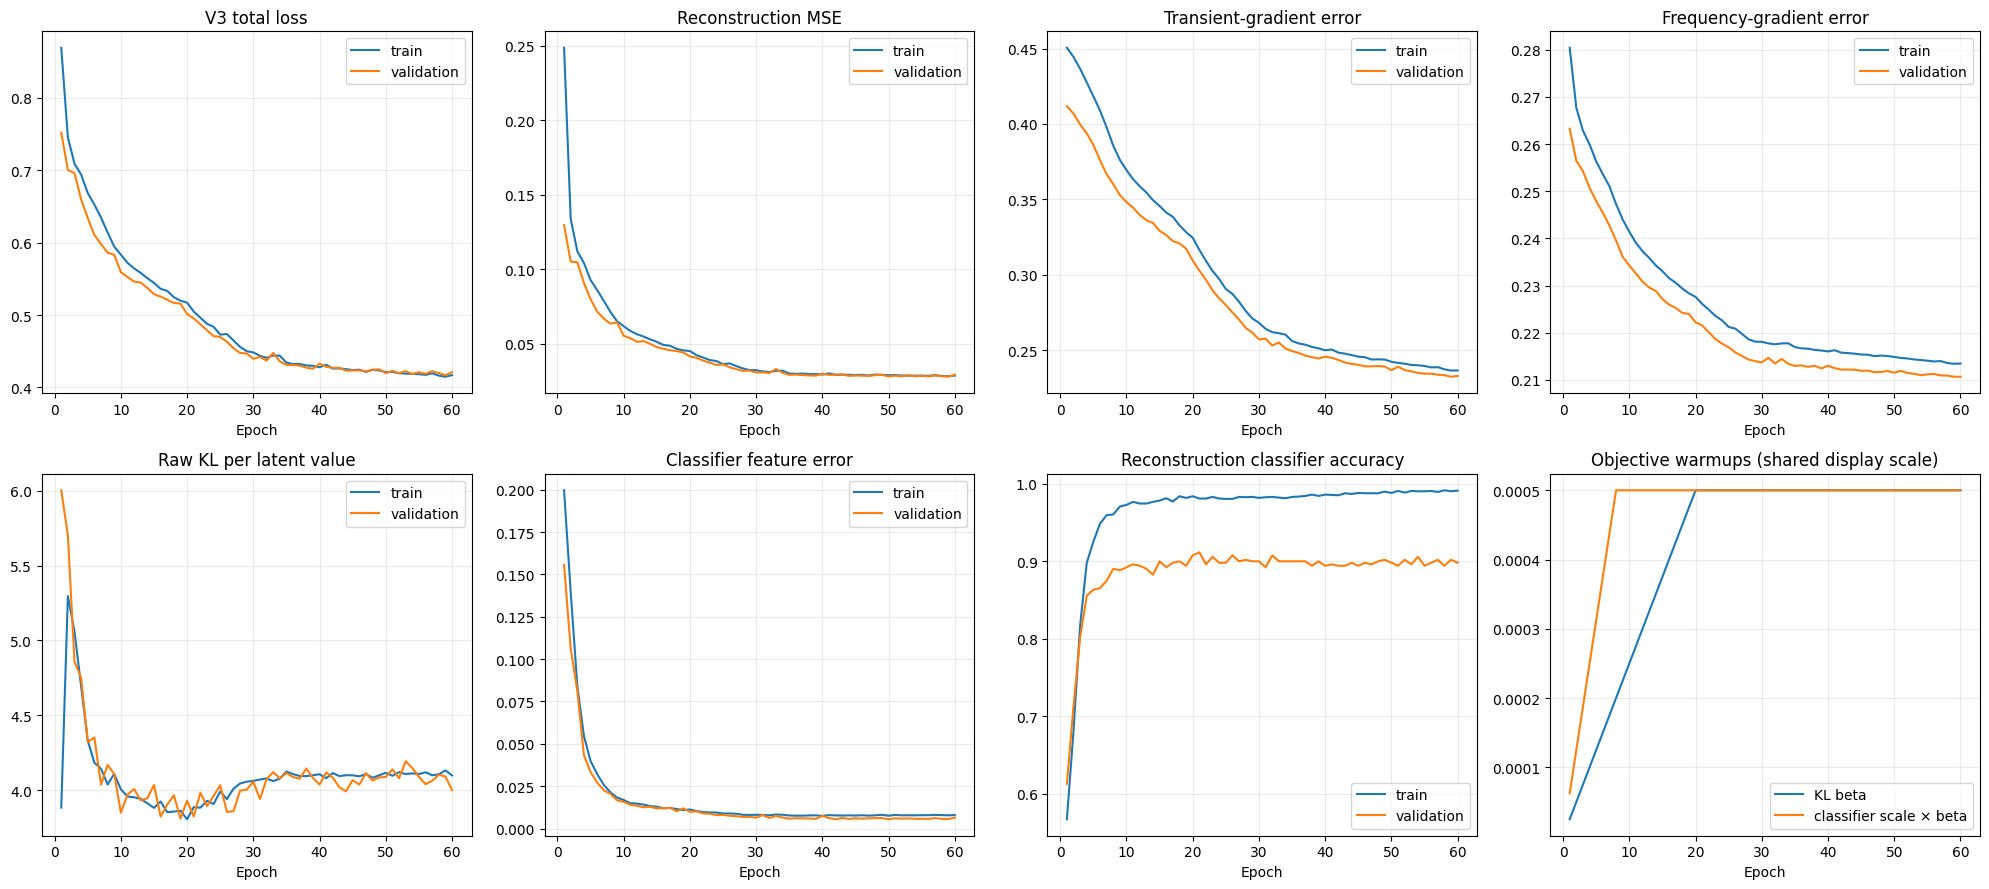

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v3\training_curves.png


In [15]:
def plot_training_history(history: Dict[str, List[float]]) -> None:
    if not history["epoch"]:
        print("No history to plot.")
        return
    epochs = history["epoch"]
    panels = [
        ("loss", "V3 total loss"),
        ("mse", "Reconstruction MSE"),
        ("time_grad", "Transient-gradient error"),
        ("freq_grad", "Frequency-gradient error"),
        ("kl_raw", "Raw KL per latent value"),
        ("classifier_feature", "Classifier feature error"),
        ("classifier_accuracy", "Reconstruction classifier accuracy"),
    ]
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    for axis, (metric, title) in zip(axes.flat, panels):
        axis.plot(epochs, history[f"train_{metric}"], label="train")
        axis.plot(epochs, history[f"val_{metric}"], label="validation")
        axis.set_title(title)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        axis.legend()
    axes.flat[-1].plot(epochs, history["beta"], label="KL beta")
    axes.flat[-1].plot(
        epochs,
        np.asarray(history["classifier_scale"]) * cfg.BETA_KL,
        label="classifier scale × beta",
    )
    axes.flat[-1].set_title("Objective warmups (shared display scale)")
    axes.flat[-1].set_xlabel("Epoch")
    axes.flat[-1].grid(alpha=0.25)
    axes.flat[-1].legend()
    fig.tight_layout()
    figure_path = OUTPUT_DIR / "training_curves.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)


plot_training_history(history)


## 14. Held-out V3 reconstruction metrics

The deterministic posterior-mean reconstruction is evaluated with shared V2
metrics plus classifier feature/label consistency. Generated-sample classifier
accuracy is reported separately because the same frozen classifier participates
in the V3 training loss and is not an independent realism judge.


In [16]:
@torch.no_grad()
def evaluate_detail_metrics(
    model: ConditionalVAE,
    loader: DataLoader,
    max_batches: Optional[int] = None,
) -> Dict[str, float]:
    model.eval()
    frozen_classifier.eval()
    totals = {
        "spectral_convergence": 0.0,
        "time_gradient_ratio": 0.0,
        "frequency_gradient_ratio": 0.0,
        "time_gradient_cosine": 0.0,
        "frequency_gradient_cosine": 0.0,
        "target_classifier_accuracy": 0.0,
        "reconstruction_classifier_accuracy": 0.0,
    }
    sample_count = 0
    epsilon = 1e-8
    for batch_index, (x, labels, _) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        reconstruction, _, _ = model(x, labels, sample_latent=False)
        batch_size = len(x)

        target_dt = first_difference(x, -1).flatten(1)
        recon_dt = first_difference(reconstruction, -1).flatten(1)
        target_df = first_difference(x, -2).flatten(1)
        recon_df = first_difference(reconstruction, -2).flatten(1)
        spectral = (
            (reconstruction - x).flatten(1).norm(dim=1)
            / (x.flatten(1).norm(dim=1) + epsilon)
        )
        time_ratio = recon_dt.abs().mean(1) / (target_dt.abs().mean(1) + epsilon)
        freq_ratio = recon_df.abs().mean(1) / (target_df.abs().mean(1) + epsilon)

        classifier_labels = classifier_target_ids[labels]
        _, target_logits = classifier_features_and_logits(to_classifier_scale(x))
        _, reconstruction_logits = classifier_features_and_logits(
            to_classifier_scale(reconstruction)
        )
        values = {
            "spectral_convergence": spectral,
            "time_gradient_ratio": time_ratio,
            "frequency_gradient_ratio": freq_ratio,
            "time_gradient_cosine": F.cosine_similarity(recon_dt, target_dt, dim=1),
            "frequency_gradient_cosine": F.cosine_similarity(recon_df, target_df, dim=1),
            "target_classifier_accuracy": (
                target_logits.argmax(1) == classifier_labels
            ).float(),
            "reconstruction_classifier_accuracy": (
                reconstruction_logits.argmax(1) == classifier_labels
            ).float(),
        }
        for key, value in values.items():
            totals[key] += float(value.sum())
        sample_count += batch_size
    return {key: value / sample_count for key, value in totals.items()}


test_metrics = run_epoch(
    model,
    test_loader,
    beta=cfg.BETA_KL,
    classifier_scale=1.0,
    optimizer=None,
    scaler=None,
    max_batches=cfg.SMOKE_TEST_BATCHES if cfg.SMOKE_TEST else None,
)
test_metrics.update(
    evaluate_detail_metrics(
        model,
        test_loader,
        max_batches=cfg.SMOKE_TEST_BATCHES if cfg.SMOKE_TEST else None,
    )
)
print("Held-out deterministic V3 test metrics:")
for key, value in test_metrics.items():
    print(f"  {key:36s}: {value:.6f}")


Held-out deterministic V3 test metrics:
  loss                                : 0.418718
  recon                               : 0.408047
  mse                                 : 0.028063
  mae                                 : 0.126060
  multiscale                          : 0.047871
  time_grad                           : 0.234394
  freq_grad                           : 0.213203
  kl                                  : 4.111639
  kl_raw                              : 4.111639
  active_latent_fraction              : 1.000000
  classifier_feature                  : 0.005263
  classifier_label                    : 0.273118
  classifier_accuracy                 : 0.895706
  spectral_convergence                : 0.179448
  time_gradient_ratio                 : 0.751366
  frequency_gradient_ratio            : 0.542362
  time_gradient_cosine                : 0.784854
  frequency_gradient_cosine           : 0.628421
  target_classifier_accuracy          : 0.862986
  reconstruction_classifier_a

## 15. Reconstruction examples by species

The comparison below uses unseen test inputs and displays the encoder mean
$\mu$ rather than a random posterior sample, making the reconstruction panel
repeatable.


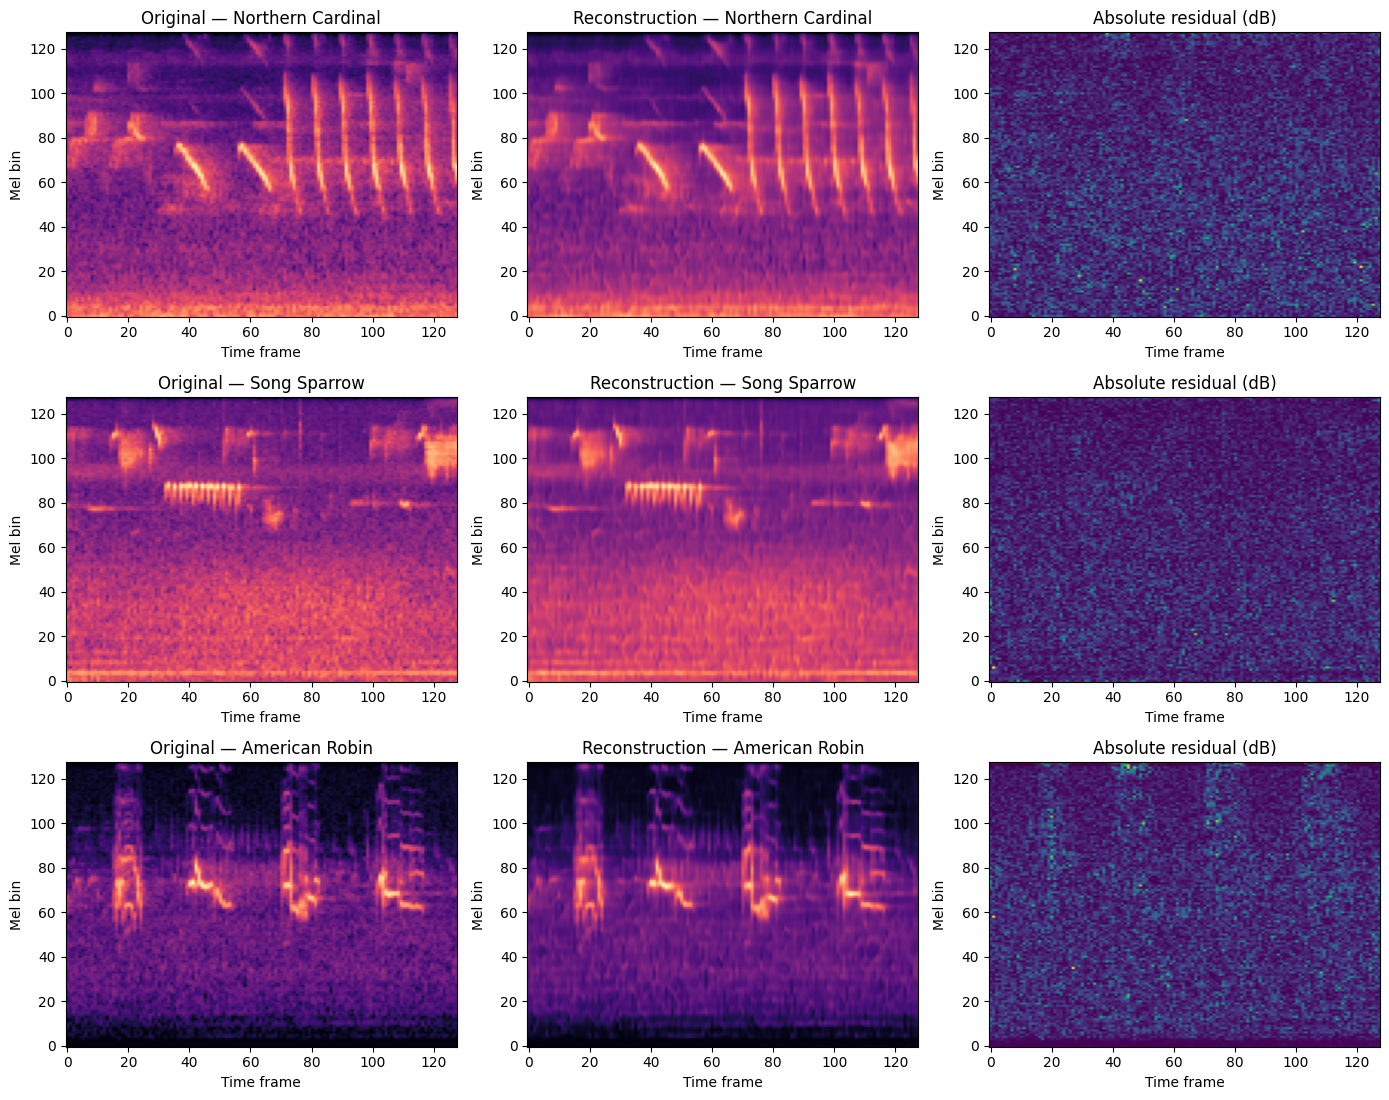

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v3\test_reconstructions.png


In [17]:
def collect_one_per_species(dataset: BirdSpectrogramDataset):
    found = {}
    for index in range(len(dataset)):
        x, label, path = dataset[index]
        label_id = int(label)
        if label_id not in found:
            found[label_id] = (x, label, path)
        if len(found) == len(label_to_id):
            break
    return [found[index] for index in range(len(label_to_id))]


@torch.no_grad()
def plot_reconstructions(model: ConditionalVAE) -> None:
    examples = collect_one_per_species(test_dataset)
    x = torch.stack([item[0] for item in examples]).to(DEVICE)
    labels = torch.stack([item[1] for item in examples]).to(DEVICE)
    model.eval()
    reconstructions, _, _ = model(x, labels, sample_latent=False)

    fig, axes = plt.subplots(len(examples), 3, figsize=(14, 3.7 * len(examples)))
    for row in range(len(examples)):
        original = to_display_scale(x[row, 0])
        reconstructed = to_display_scale(reconstructions[row, 0])
        residual = np.abs(original - reconstructed)
        common_min = min(float(original.min()), float(reconstructed.min()))
        common_max = max(float(original.max()), float(reconstructed.max()))
        species = id_to_label[int(labels[row])]

        axes[row, 0].imshow(original, origin="lower", aspect="auto", cmap="magma",
                            vmin=common_min, vmax=common_max)
        axes[row, 1].imshow(reconstructed, origin="lower", aspect="auto", cmap="magma",
                            vmin=common_min, vmax=common_max)
        axes[row, 2].imshow(residual, origin="lower", aspect="auto", cmap="viridis")
        axes[row, 0].set_title(f"Original — {species}")
        axes[row, 1].set_title(f"Reconstruction — {species}")
        axes[row, 2].set_title("Absolute residual (dB)")
        for axis in axes[row]:
            axis.set_xlabel("Time frame")
            axis.set_ylabel("Mel bin")

    fig.tight_layout()
    figure_path = OUTPUT_DIR / "test_reconstructions.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)


if best_path.exists():
    plot_reconstructions(model)
else:
    print("Train the model first.")


## 16. V3 posterior-anchor generation and detail checks

V2 sampled an independent moment-matched Gaussian at every spatial latent
position, which discarded correlations between neighboring positions. V3 stores
a bounded per-species bank of posterior `(mu, logvar)` anchors and adds
low-temperature posterior noise. This improves fidelity while remaining
stochastic, but it is not a fully independent unconditional prior. Every anchor
path is recorded in the generated manifest.

Waveforms remain an external post-process and should use
`scripts/05_export_generated_audio.py --no-peak-normalize`.


Saved V3 posterior bank: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v3\class_conditional_posterior_bank.pt {'Northern Cardinal': 256, 'Song Sparrow': 256, 'American Robin': 256}


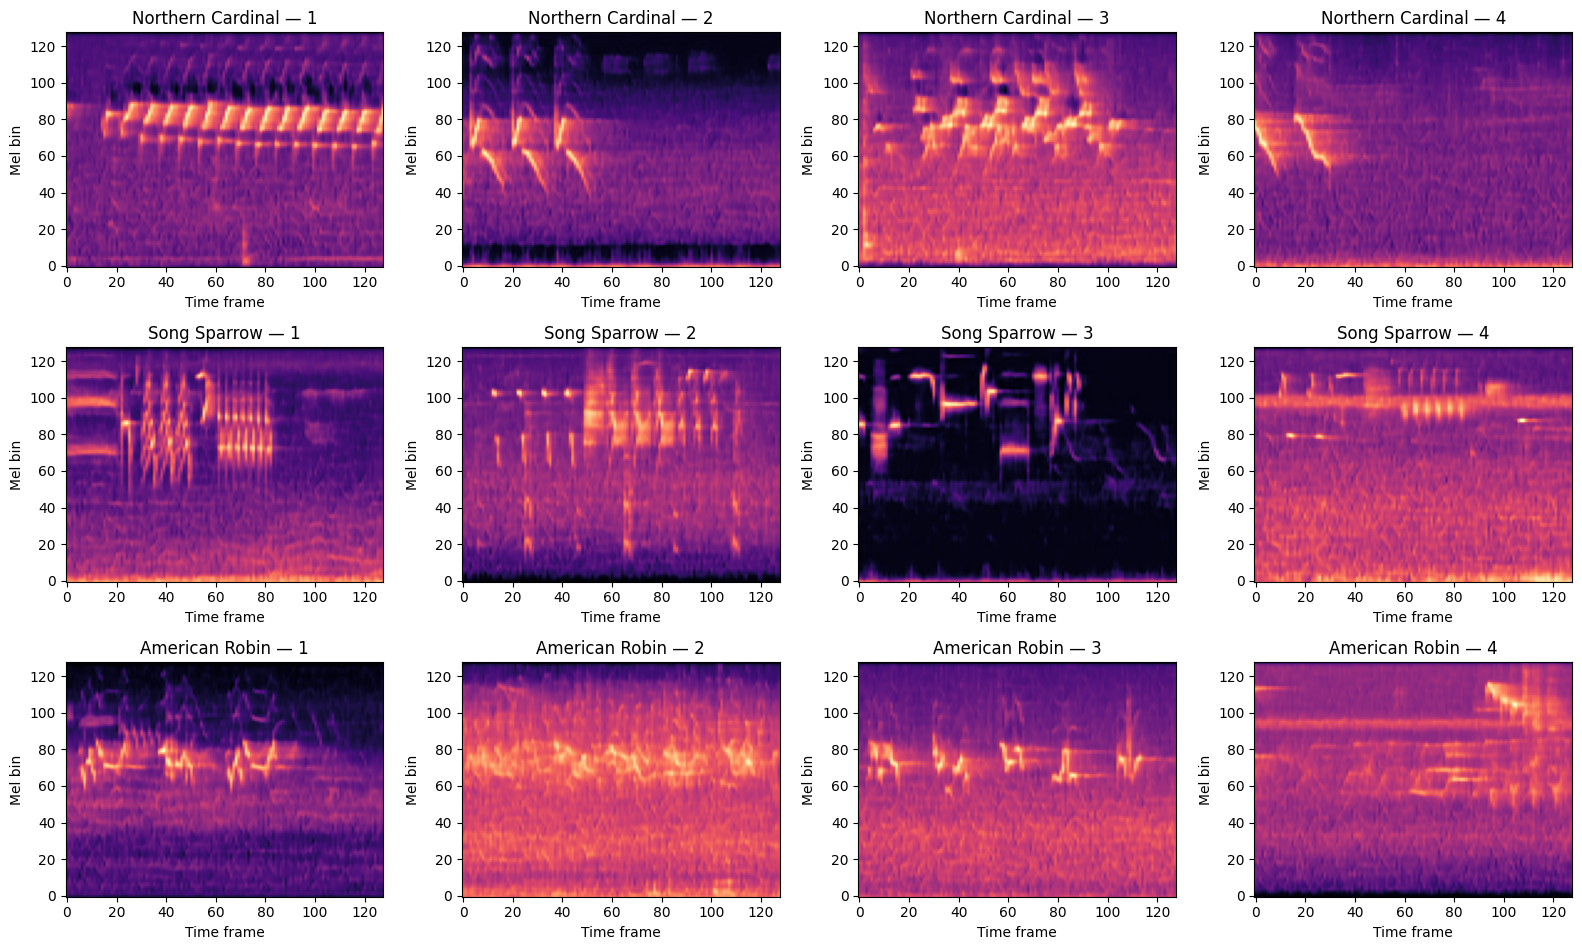

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v3\conditional_samples.png


,species,real_time_gradient_energy,real_frequency_gradient_energy,generated_time_gradient_energy,generated_frequency_gradient_energy,time_detail_ratio,frequency_detail_ratio
0,Northern Cardinal,0.286307,0.201249,0.231979,0.115797,0.810246,0.575391
1,Song Sparrow,0.272544,0.210466,0.227112,0.109018,0.833302,0.517986
2,American Robin,0.247091,0.195077,0.190268,0.106595,0.770033,0.546425


Notebook audio export is disabled. Use scripts/05_export_generated_audio.py with --no-peak-normalize.


In [18]:
@torch.no_grad()
def fit_class_conditional_posterior_bank(
    model: ConditionalVAE,
    loader: DataLoader,
) -> Dict[int, Dict[str, object]]:
    model.eval()
    collected = {
        label_id: {"mu": [], "logvar": [], "paths": []}
        for label_id in id_to_label
    }
    for x, labels, paths in loader:
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mu, logvar = model.encode(x, labels)
        for index, label in enumerate(labels.tolist()):
            bank = collected[label]
            if len(bank["mu"]) >= cfg.PRIOR_BANK_SIZE_PER_SPECIES:
                continue
            bank["mu"].append(mu[index].detach().cpu())
            bank["logvar"].append(logvar[index].detach().cpu())
            bank["paths"].append(str(paths[index]))
        if all(
            len(bank["mu"]) >= cfg.PRIOR_BANK_SIZE_PER_SPECIES
            for bank in collected.values()
        ):
            break

    posterior_bank: Dict[int, Dict[str, object]] = {}
    for label_id, bank in collected.items():
        if not bank["mu"]:
            raise RuntimeError(f"Posterior bank is empty for label {label_id}")
        posterior_bank[label_id] = {
            "mu": torch.stack(bank["mu"]),
            "logvar": torch.stack(bank["logvar"]),
            "paths": list(bank["paths"]),
        }

    prior_path = OUTPUT_DIR / "class_conditional_posterior_bank.pt"
    torch.save(
        {
            "banks": posterior_bank,
            "temperature": cfg.PRIOR_TEMPERATURE,
            "label_to_id": label_to_id,
            "fitted_split": "train",
            "sampling_type": "per_species_posterior_anchor_mixture",
        },
        prior_path,
    )
    print(
        "Saved V3 posterior bank:",
        prior_path,
        {id_to_label[k]: len(v["mu"]) for k, v in posterior_bank.items()},
    )
    return posterior_bank


@torch.no_grad()
def generate_and_save_samples(
    model: ConditionalVAE,
    samples_per_species: int,
    posterior_bank: Dict[int, Dict[str, object]],
) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    labels = torch.arange(len(label_to_id), device=DEVICE).repeat_interleave(
        samples_per_species
    )
    sample_generator = torch.Generator(device=DEVICE.type).manual_seed(cfg.SEED + 100)
    latent_samples = []
    anchor_paths = []
    for label in labels.tolist():
        bank = posterior_bank[label]
        anchor_index = int(
            torch.randint(
                len(bank["mu"]), (), generator=sample_generator, device=DEVICE
            )
        )
        mu = bank["mu"][anchor_index].to(DEVICE)
        logvar = bank["logvar"][anchor_index].to(DEVICE)
        epsilon = torch.randn(
            mu.shape, generator=sample_generator, device=DEVICE, dtype=mu.dtype
        )
        latent_samples.append(
            mu + cfg.PRIOR_TEMPERATURE * torch.exp(0.5 * logvar) * epsilon
        )
        anchor_paths.append(bank["paths"][anchor_index])
    samples = model.decode(torch.stack(latent_samples), labels)

    generated_dir = OUTPUT_DIR / "generated_npy"
    classifier_dir = OUTPUT_DIR / "classifier_input"
    generated_dir.mkdir(parents=True, exist_ok=True)
    classifier_dir.mkdir(parents=True, exist_ok=True)
    records = []
    for index, (sample, label, anchor_path) in enumerate(
        zip(samples, labels, anchor_paths)
    ):
        label_id = int(label)
        species = id_to_label[label_id]
        species_slug = species.lower().replace(" ", "_").replace("'", "")
        species_index = index % samples_per_species
        species_dir = generated_dir / species_slug
        classifier_species_dir = classifier_dir / species_slug
        species_dir.mkdir(parents=True, exist_ok=True)
        classifier_species_dir.mkdir(parents=True, exist_ok=True)
        filename = f"vae_v3_{species_slug}_{species_index:03d}.npy"
        path = species_dir / filename
        normalized_array = sample.detach().cpu().float().numpy().astype(np.float32)
        np.save(path, normalized_array)

        logmel_db = normalized_array[0] * TRAIN_STD + TRAIN_MEAN
        relative_db = np.clip(logmel_db - float(logmel_db.max()), -80.0, 0.0)
        classifier_array = (relative_db * (2.0 / 80.0) + 1.0)[None]
        classifier_path = classifier_species_dir / filename
        np.save(classifier_path, classifier_array.astype(np.float32))
        records.append(
            {
                "filename": filename,
                "spec_path": str(path.resolve()),
                "classifier_spec_path": str(classifier_path.resolve()),
                "name": species,
                "label_id": label_id,
                "source_model": "spatial_detail_conditional_vae_v3_posterior_mixture",
                "anchor_spec_path": str(anchor_path),
                "posterior_temperature": cfg.PRIOR_TEMPERATURE,
            }
        )
    pd.DataFrame(records).to_csv(OUTPUT_DIR / "generated_manifest.csv", index=False)
    return samples.cpu(), labels.cpu()


def plot_generated_samples(
    samples: torch.Tensor,
    labels: torch.Tensor,
    samples_per_species_to_show: int = 4,
) -> None:
    fig, axes = plt.subplots(
        len(label_to_id), samples_per_species_to_show,
        figsize=(4 * samples_per_species_to_show, 3.2 * len(label_to_id)),
        squeeze=False,
    )
    for label_id in range(len(label_to_id)):
        indices = torch.where(labels == label_id)[0][:samples_per_species_to_show]
        for col, index in enumerate(indices):
            axes[label_id, col].imshow(
                to_display_scale(samples[index, 0]),
                origin="lower", aspect="auto", cmap="magma"
            )
            axes[label_id, col].set_title(f"{id_to_label[label_id]} — {col + 1}")
            axes[label_id, col].set_xlabel("Time frame")
            axes[label_id, col].set_ylabel("Mel bin")
    fig.tight_layout()
    figure_path = OUTPUT_DIR / "conditional_samples.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)


@torch.no_grad()
def collect_real_detail_statistics(loader: DataLoader) -> pd.DataFrame:
    rows = []
    for x, labels, _ in loader:
        for tensor, label in zip(x, labels):
            rows.append(
                {
                    "label_id": int(label),
                    "time_gradient_energy": float(first_difference(tensor, -1).abs().mean()),
                    "frequency_gradient_energy": float(first_difference(tensor, -2).abs().mean()),
                }
            )
    return pd.DataFrame(rows)


def generated_detail_statistics(
    samples: torch.Tensor,
    labels: torch.Tensor,
    real_statistics: pd.DataFrame,
) -> pd.DataFrame:
    rows = [
        {
            "label_id": int(label),
            "time_gradient_energy": float(first_difference(tensor, -1).abs().mean()),
            "frequency_gradient_energy": float(first_difference(tensor, -2).abs().mean()),
        }
        for tensor, label in zip(samples, labels)
    ]
    generated = pd.DataFrame(rows)
    real_means = real_statistics.groupby("label_id").mean().add_prefix("real_")
    generated_means = generated.groupby("label_id").mean().add_prefix("generated_")
    comparison = real_means.join(generated_means)
    comparison["time_detail_ratio"] = (
        comparison["generated_time_gradient_energy"]
        / comparison["real_time_gradient_energy"]
    )
    comparison["frequency_detail_ratio"] = (
        comparison["generated_frequency_gradient_energy"]
        / comparison["real_frequency_gradient_energy"]
    )
    comparison.insert(0, "species", [id_to_label[index] for index in comparison.index])
    return comparison.reset_index(drop=True)


posterior_bank = fit_class_conditional_posterior_bank(model, train_loader)
generated_samples, generated_labels = generate_and_save_samples(
    model, cfg.SAMPLES_PER_SPECIES, posterior_bank
)
plot_generated_samples(generated_samples, generated_labels)
real_detail_stats = collect_real_detail_statistics(test_loader)
generated_detail_comparison = generated_detail_statistics(
    generated_samples, generated_labels, real_detail_stats
)
generated_detail_comparison.to_csv(
    OUTPUT_DIR / "generated_detail_metrics.csv", index=False
)
display(generated_detail_comparison)
audio_demo_paths = []
print(
    "Notebook audio export is disabled. Use scripts/05_export_generated_audio.py "
    "with --no-peak-normalize."
)


## 17. Latent-space inspection

This diagnostic encodes the held-out test set using $\mu$ and projects the
latent vectors to two dimensions with an SVD-based PCA implementation. Clear
class separation is not required, but the plot helps reveal whether species
information and meaningful variation are represented in latent space.


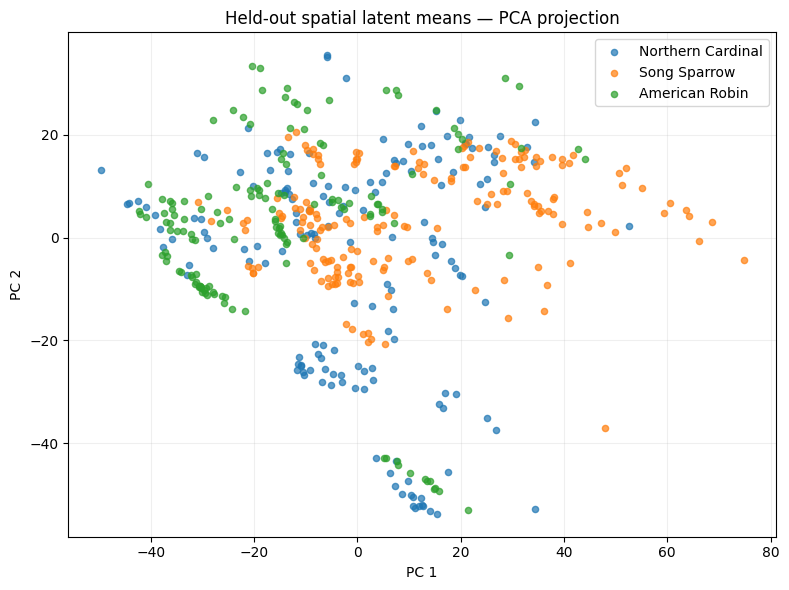

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v3\latent_pca.png


In [19]:
@torch.no_grad()
def collect_latents(
    model: ConditionalVAE,
    loader: DataLoader,
    max_samples: int = 1000,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    latent_batches = []
    label_batches = []
    collected = 0
    for x, labels, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mu, _ = model.encode(x, labels)
        latent_batches.append(mu.flatten(1).cpu().numpy())
        label_batches.append(labels.cpu().numpy())
        collected += len(x)
        if collected >= max_samples:
            break
    return (
        np.concatenate(latent_batches, axis=0)[:max_samples],
        np.concatenate(label_batches, axis=0)[:max_samples],
    )


def pca_2d(x: np.ndarray) -> np.ndarray:
    centered = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    return centered @ vt[:2].T


if best_path.exists():
    latent_vectors, latent_labels = collect_latents(model, test_loader)
    projected = pca_2d(latent_vectors)
    fig, axis = plt.subplots(figsize=(8, 6))
    for label_id, species in id_to_label.items():
        mask = latent_labels == label_id
        axis.scatter(projected[mask, 0], projected[mask, 1], s=20, alpha=0.7, label=species)
    axis.set_title("Held-out spatial latent means — PCA projection")
    axis.set_xlabel("PC 1")
    axis.set_ylabel("PC 2")
    axis.grid(alpha=0.2)
    axis.legend()
    fig.tight_layout()
    figure_path = OUTPUT_DIR / "latent_pca.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)
else:
    print("Train the model first.")


## 18. Save V3 metadata and compare against V2

The summary records the verified V3 architecture and objective, the complete
training history, posterior-anchor sampling, held-out metrics, and direct deltas
from the saved V2 run when that summary is present.


In [20]:
completed_epochs = len(history["epoch"])
best_index = int(np.argmin(history["val_loss"])) if history["val_loss"] else None
best_epoch = int(history["epoch"][best_index]) if best_index is not None else None

v2_summary_path = V2_OUTPUT_DIR / "run_summary.json"
v2_summary = (
    json.loads(v2_summary_path.read_text(encoding="utf-8"))
    if v2_summary_path.exists()
    else None
)
comparison_to_v2 = None
if v2_summary is not None:
    v2_test = v2_summary.get("test_metrics", {})
    shared_metrics = [
        "mse", "mae", "spectral_convergence", "time_gradient_ratio",
        "frequency_gradient_ratio", "time_gradient_cosine",
        "frequency_gradient_cosine",
    ]
    comparison_to_v2 = {
        metric: {
            "v2": float(v2_test[metric]),
            "v3": float(test_metrics[metric]),
            "v3_minus_v2": float(test_metrics[metric] - v2_test[metric]),
        }
        for metric in shared_metrics
        if metric in v2_test and metric in test_metrics
    }

run_summary = {
    "model": "spatial_detail_classifier_regularized_conditional_vae_v3",
    "execution_mode": "training" if cfg.RUN_TRAINING else "existing_checkpoint_evaluation",
    "target_species": list(cfg.TARGET_SPECIES),
    "label_to_id": label_to_id,
    "input_shape": [cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE],
    "latent_shape": [cfg.LATENT_CHANNELS, cfg.LATENT_SIZE, cfg.LATENT_SIZE],
    "latent_dim": model.latent_dim,
    "class_embed_dim": cfg.CLASS_EMBED_DIM,
    "base_channels": cfg.BASE_CHANNELS,
    "total_parameters": parameter_counts["total"],
    "trainable_parameters": parameter_counts["trainable"],
    "batch_size": cfg.BATCH_SIZE,
    "learning_rate": cfg.LEARNING_RATE,
    "beta_kl": cfg.BETA_KL,
    "kl_warmup_epochs": cfg.KL_WARMUP_EPOCHS,
    "free_nats_per_channel": cfg.FREE_NATS_PER_CHANNEL,
    "classifier_checkpoint": str(CLASSIFIER_CHECKPOINT_PATH.resolve()),
    "loss_weights": {
        "event": cfg.EVENT_WEIGHT,
        "multiscale": cfg.MULTISCALE_WEIGHT,
        "time_gradient": cfg.TIME_GRAD_WEIGHT,
        "frequency_gradient": cfg.FREQ_GRAD_WEIGHT,
        "classifier_feature": cfg.CLASSIFIER_FEATURE_WEIGHT,
        "classifier_label": cfg.CLASSIFIER_LABEL_WEIGHT,
    },
    "completed_epochs": completed_epochs,
    "best_epoch": best_epoch,
    "best_validation_loss": (
        float(history["val_loss"][best_index]) if best_index is not None else None
    ),
    "best_validation_mse": (
        float(history["val_mse"][best_index]) if best_index is not None else None
    ),
    "best_validation_classifier_accuracy": (
        float(history["val_classifier_accuracy"][best_index])
        if best_index is not None else None
    ),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "generated_detail_metrics": generated_detail_comparison.to_dict(orient="records"),
    "sampling_prior": {
        "type": "per_species_posterior_anchor_mixture",
        "fitted_split": "train",
        "bank_size_per_species": cfg.PRIOR_BANK_SIZE_PER_SPECIES,
        "temperature": cfg.PRIOR_TEMPERATURE,
        "guardrail": "high-fidelity stochastic variants, not an independent unconditional prior",
    },
    "audio_export": {
        "performed_in_notebook": False,
        "external_script": "scripts/05_export_generated_audio.py",
        "required_flag": "--no-peak-normalize",
    },
    "comparison_to_v2": comparison_to_v2,
    "training_section_seconds": float(
        total_training_seconds if total_training_seconds > 0
        else sum(history["epoch_seconds"])
    ),
    "mean_epoch_seconds": (
        float(np.mean(history["epoch_seconds"])) if history["epoch_seconds"] else None
    ),
    "peak_allocated_cuda_gb": peak_memory_gb,
    "device": str(DEVICE),
    "smoke_test": cfg.SMOKE_TEST,
    "best_checkpoint": str(best_path.resolve()),
}

summary_path = OUTPUT_DIR / "run_summary.json"
with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(run_summary, handle, indent=2, ensure_ascii=False)
print(json.dumps(run_summary, indent=2, ensure_ascii=False))
print("Saved V3 run summary:", summary_path)

generated_manifest_path = OUTPUT_DIR / "generated_manifest.csv"
generated_df = pd.read_csv(generated_manifest_path)
assert best_path.stat().st_size > 0
assert len(generated_df) == len(label_to_id) * cfg.SAMPLES_PER_SPECIES
assert generated_df["spec_path"].map(lambda p: Path(p).exists()).all()
assert generated_df["anchor_spec_path"].map(lambda p: Path(p).exists()).all()
print("V3 final artifact checks passed.")


{
  "model": "spatial_detail_classifier_regularized_conditional_vae_v3",
  "execution_mode": "existing_checkpoint_evaluation",
  "target_species": [
    "Northern Cardinal",
    "Song Sparrow",
    "American Robin"
  ],
  "label_to_id": {
    "Northern Cardinal": 0,
    "Song Sparrow": 1,
    "American Robin": 2
  },
  "input_shape": [
    1,
    128,
    128
  ],
  "latent_shape": [
    16,
    16,
    16
  ],
  "latent_dim": 4096,
  "class_embed_dim": 64,
  "base_channels": 32,
  "total_parameters": 5365025,
  "trainable_parameters": 5365025,
  "batch_size": 24,
  "learning_rate": 0.0002,
  "beta_kl": 0.0005,
  "kl_warmup_epochs": 20,
  "free_nats_per_channel": 0.25,
  "classifier_checkpoint": "C:\\Users\\sheng\\Documents\\1508_project\\bird_song_gen\\classifier_artifacts\\Harvey_classifier\\best.pt",
  "loss_weights": {
    "event": 1.5,
    "multiscale": 0.25,
    "time_gradient": 0.6,
    "frequency_gradient": 0.6,
    "classifier_feature": 0.08,
    "classifier_label": 0.03
  },


## 19. Interpretation, limitations, and literature record

Do not declare V3 better from its composite loss alone. Compare shared held-out
MSE, spectral convergence, gradient ratios/cosines, visual preservation of
narrow tracks, diversity, external recognition, and listening. The project
classifier participates in the V3 loss, so its accuracy is a consistency check,
not an independent realism metric.

The posterior-anchor mixture deliberately prioritizes fidelity over a fully
independent standard-normal prior. Generated manifests retain anchor paths so
this limitation is auditable. A future latent diffusion prior can replace this
bank while retaining the V3 encoder/decoder. Griffin–Lim remains a separate
waveform bottleneck and is not evidence that the spectrogram model failed.

### References retained from V2

- Vahdat & Kautz, **NVAE: A Deep Hierarchical Variational Autoencoder** (2020),
  https://arxiv.org/abs/2007.03898
- Child, **Very Deep VAEs Generalize Autoregressive Models and Can Outperform
  Them on Images** (2021), https://arxiv.org/abs/2011.10650
- Sønderby et al., **Ladder Variational Autoencoders** (2016),
  https://arxiv.org/abs/1602.02282
- Tomczak & Welling, **VAE with a VampPrior** (2018),
  https://proceedings.mlr.press/v84/tomczak18a.html
- Caillon & Esling, **RAVE: A variational autoencoder for fast and high-quality
  neural audio synthesis** (2021), https://arxiv.org/abs/2111.05011
- Yamamoto, Song & Kim, **Parallel WaveGAN** (2020),
  https://arxiv.org/abs/1910.11480
- Mathieu, Couprie & LeCun, **Deep multi-scale video prediction beyond mean
  square error** (2016), https://arxiv.org/abs/1511.05440
- Bhatia & Kinnunen, **An Initial study on Birdsong Re-synthesis Using Neural
  Vocoders** (2022), https://arxiv.org/abs/2209.10479
- Song & Ta, **Towards High-Fidelity and Controllable Bioacoustic Generation via
  Enhanced Diffusion Learning** (2025), https://arxiv.org/abs/2509.00318

### References added for V3 changes

- Kingma & Welling, **Auto-Encoding Variational Bayes** (2014),
  https://arxiv.org/abs/1312.6114
- Kingma et al., **Improving Variational Inference with Inverse Autoregressive
  Flow** (2016), Appendix C: free-bits objective,
  https://arxiv.org/abs/1606.04934
- Johnson, Alahi & Fei-Fei, **Perceptual Losses for Real-Time Style Transfer and
  Super-Resolution** (2016), motivating frozen feature-space consistency,
  https://arxiv.org/abs/1603.08155

These references motivate the architecture and objectives; they do not by
themselves establish bird-audio quality. That claim must come from the saved
metrics, spectrograms, external recognizers, and listening tests.
